# Historical exploration: use the matching older environment

        These exploratory cells and outputs are preserved from before the 1.5 migration.
        They include retired APIs and are not validated on PIRATE 1.5. Use
        [the active saved-map notebook](peakfinder_tests/inspect_peakfinders_on_snrmap.ipynb)
        or [the analytic-map notebook](peakfinder_tests/inspect_peakfinders_on_fast_snrmap.ipynb)
        for current full-band experiments.

# Display a dequantized PIRATE observation

The intensity chunks `t0`, `t1`, `t2`, ... are dequantized, binned for display, concatenated along time, and shown as one continuous observation.

In [26]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from pirate_frb.core import AssembledFrame

In [27]:
# Change this path if your acquisition is elsewhere.
acqdir = Path("/home/mtrudu/chordsim/grouptest")

intensity_files = sorted(
    path for path in acqdir.glob("frame_b*_t*.asdf")
    if not path.name.endswith("_snrmap.asdf")
)

if not intensity_files:
    raise FileNotFoundError(f"No intensity ASDF files found in {acqdir}")

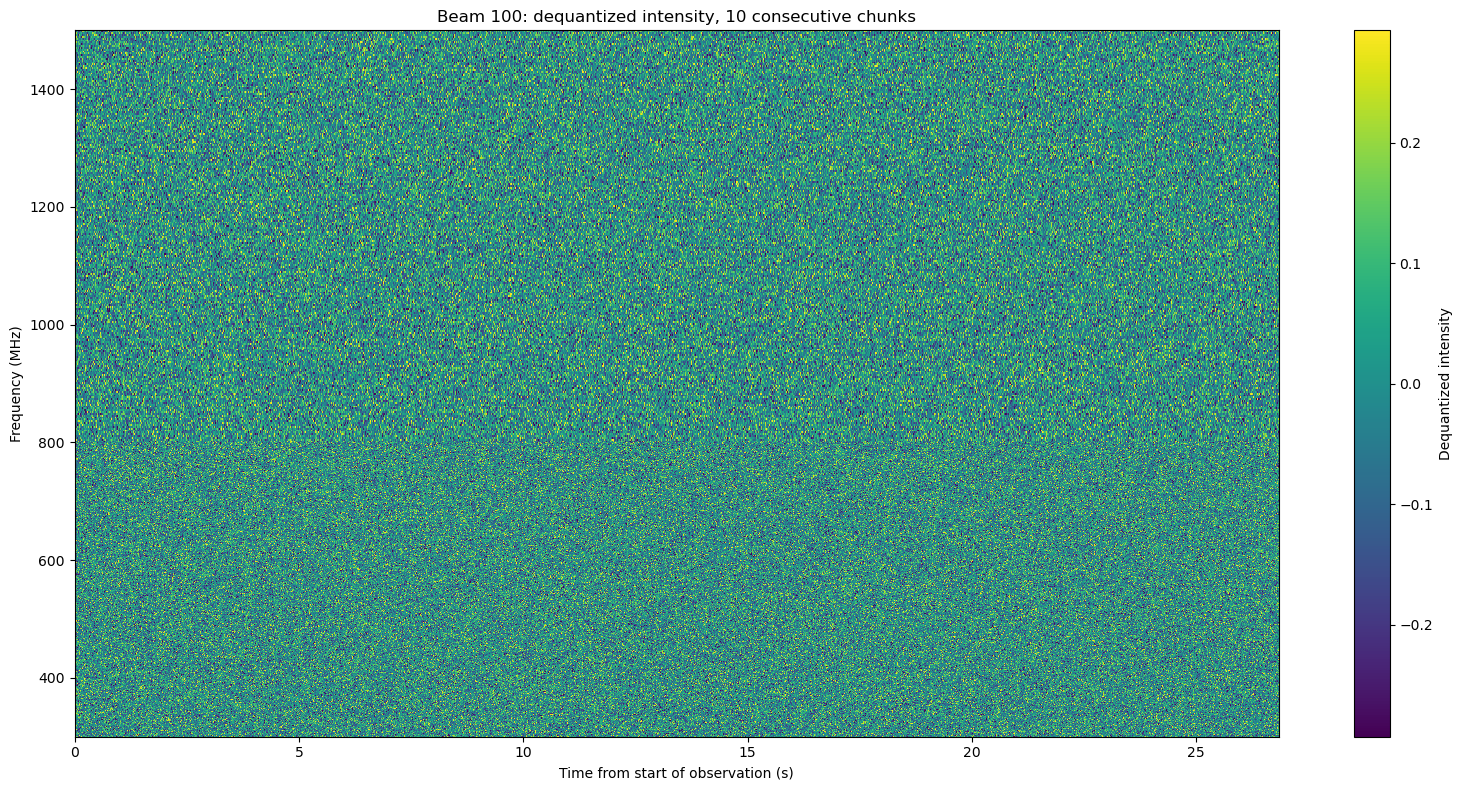

In [28]:
# Average adjacent samples to keep the displayed image reasonably sized.
# Set both values to 1 for full resolution (about 2.3 GB here).
frequency_bin = 16
time_bin = 4

display_chunks = []
first_frame = None

for intensity_path in intensity_files:
    frame = AssembledFrame.from_asdf(str(intensity_path))
    if first_frame is None:
        first_frame = frame

    intensity = frame.dequantize()  # float32, shape (frequency, time)
    nfreq = (intensity.shape[0] // frequency_bin) * frequency_bin
    ntime = (intensity.shape[1] // time_bin) * time_bin
    display_chunk = intensity[:nfreq, :ntime].reshape(
        nfreq // frequency_bin, frequency_bin,
        ntime // time_bin, time_bin,
    ).mean(axis=(1, 3))
    display_chunks.append(display_chunk)

observation = np.concatenate(display_chunks, axis=1)
metadata = first_frame.metadata
sample_ms = metadata.dt_ns_per_seq * metadata.seq_per_frb_time_sample / 1.0e6
duration_s = len(intensity_files) * first_frame.ntime * sample_ms / 1000.0
display_nfreq = observation.shape[0] * frequency_bin

# Robust limits keep isolated bright samples from washing out the image.
vmin, vmax = np.nanpercentile(observation, (1, 99))

fig, ax = plt.subplots(figsize=(16, 8))
# Original frequency edges: length = frame.nfreq + 1.
raw_freq_edges_MHz = np.asarray(
    metadata.get_channel_freq_edges(),
    dtype=np.float64,
)

# Each displayed row averages `frequency_bin` consecutive raw channels.
nfreq_used = observation.shape[0] * frequency_bin
display_freq_edges_MHz = raw_freq_edges_MHz[
    np.arange(0, nfreq_used + 1, frequency_bin)
]

# Time edges corresponding to the time-averaged samples.
display_dt_s = time_bin * sample_ms / 1000.0
display_time_edges_s = (
    np.arange(observation.shape[1] + 1) * display_dt_s
)



image = ax.pcolormesh(
    display_time_edges_s,
    display_freq_edges_MHz,
    observation,
    shading="flat",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    rasterized=True,
)

ax.set_xlabel("Time from start of observation (s)")
ax.set_ylabel("Frequency (MHz)")
ax.set_title(
    f"Beam {first_frame.beam_id}: dequantized intensity, "
    f"{len(intensity_files)} consecutive chunks"
)

fig.colorbar(image, ax=ax, label="Dequantized intensity")
fig.tight_layout()
plt.show()


Saved: /home/mtrudu/src/pirate-updated/bowtie_dm_reach_overlay.png
dm_reach= 4: shape=(9, 11), active cells=37
dm_reach= 8: shape=(17, 19), active cells=101
dm_reach=16: shape=(33, 35), active cells=325
dm_reach=32: shape=(65, 67), active cells=1159


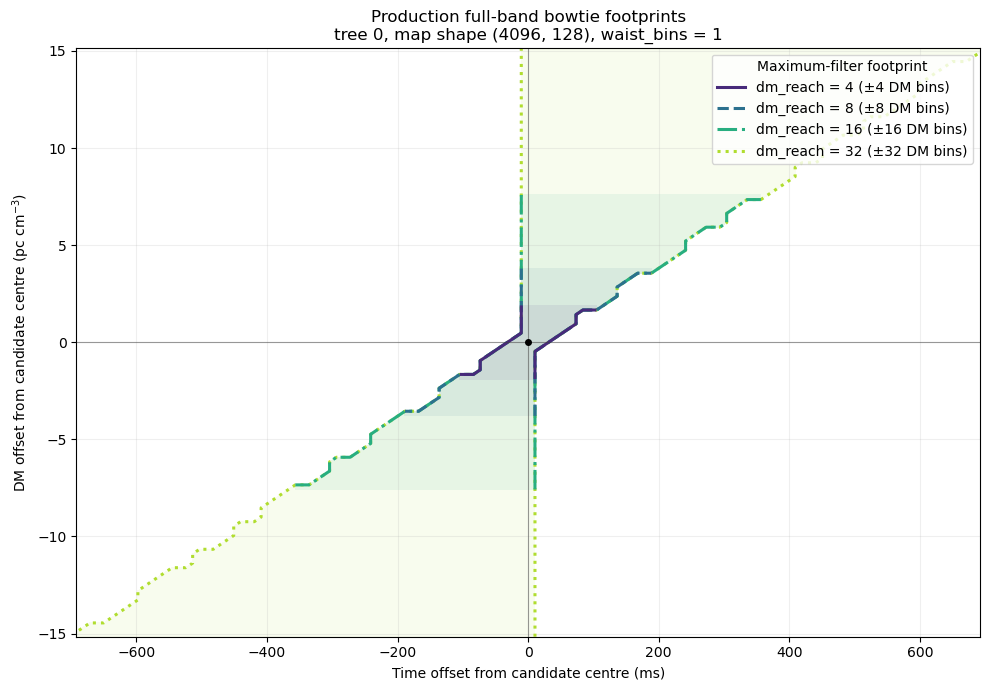

In [29]:
from pathlib import Path
from matplotlib.lines import Line2D

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from pirate_frb import DedispersionConfig, DedispersionPlan
from pirate_frb.Peakfinders import PeakFinderGeometry


# Configuration
tree_index = 0
dm_reaches = (4, 8, 16, 32)
waist_bins = 1
save_figure = True

config_path = Path("configs/dedispersion/chord_sb2_et.yml").resolve()


# Reconstruct the plan in the same way as the offline pipeline.
config = DedispersionConfig.from_yaml(str(config_path))

producer_plan = DedispersionPlan(
    config,
    gpu_runnable=True,
)

offline_plan = DedispersionPlan.make_incomplete_plan_from_yaml(
    config.to_yaml_string(),
    producer_plan.to_yaml_string(),
)


# Construct the exact production maximum-filter footprints.
footprints = []

for dm_reach in sorted(dm_reaches):
    geometry = PeakFinderGeometry.from_plan(
        offline_plan,
        tree_index,
        dm_reach=dm_reach,
        waist_bins=waist_bins,
        peakfinder="full_band",
    )

    footprint = cp.asnumpy(geometry.full_band_bowtie)

    # Convert native map-bin offsets to physical coordinates.
    dm_offset = (
        np.arange(footprint.shape[0]) - geometry.dm_radius
    ) * geometry.dm_step

    time_offset_ms = (
        np.arange(footprint.shape[1]) - geometry.time_radius
    ) * geometry.time_step_s * 1.0e3

    footprints.append(
        (dm_reach, geometry, footprint, dm_offset, time_offset_ms)
    )


# Plot the largest footprint first so smaller footprints remain visible.
colors = plt.colormaps["viridis"](
    np.linspace(0.12, 0.88, len(footprints))
)
line_styles = ("-", "--", "-.", ":")

fig, ax = plt.subplots(figsize=(10, 7))

for index in reversed(range(len(footprints))):
    dm_reach, geometry, footprint, dm_offset, time_offset_ms = (
        footprints[index]
    )

    color = colors[index]
    line_style = line_styles[index % len(line_styles)]

    # Light transparent interior.
    ax.contourf(
        time_offset_ms,
        dm_offset,
        footprint.astype(np.uint8),
        levels=(0.5, 1.5),
        colors=(color,),
        alpha=0.08,
    )

    # Exact Boolean-footprint boundary.
    ax.contour(
        time_offset_ms,
        dm_offset,
        footprint.astype(np.uint8),
        levels=(0.5,),
        colors=(color,),
        linewidths=2.2,
        linestyles=(line_style,),
    )


legend_handles = [
    Line2D(
        (0,),
        (0,),
        color=colors[index],
        linestyle=line_styles[index % len(line_styles)],
        linewidth=2.2,
        label=f"dm_reach = {dm_reach} (±{dm_reach} DM bins)",
    )
    for index, (dm_reach, *_rest) in enumerate(footprints)
]

plan_tree = offline_plan.trees[tree_index]

ax.axhline(0, color="0.25", linewidth=0.8, alpha=0.5)
ax.axvline(0, color="0.25", linewidth=0.8, alpha=0.5)
ax.plot(0, 0, "ko", markersize=4, zorder=10)

ax.set_xlabel("Time offset from candidate centre (ms)")
ax.set_ylabel(r"DM offset from candidate centre (pc cm$^{-3}$)")

ax.set_title(
    "Production full-band bowtie footprints\n"
    f"tree {tree_index}, "
    f"map shape ({int(plan_tree.ndm_out)}, {int(plan_tree.nt_out)}), "
    f"waist_bins = {waist_bins}"
)

ax.grid(alpha=0.2)
ax.legend(
    handles=legend_handles,
    title="Maximum-filter footprint",
)

fig.tight_layout()

if save_figure:
    output_path = Path("bowtie_dm_reach_overlay.png")
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {output_path.resolve()}")

for dm_reach, geometry, footprint, *_rest in footprints:
    print(
        f"dm_reach={dm_reach:2d}: "
        f"shape={footprint.shape}, "
        f"active cells={np.count_nonzero(footprint)}"
    )

plt.show()

Tree 0: time sampling = 20.9715 ms/bin, DM sampling = 0.47389 pc cm^-3/bin
dm_reach= 4: footprint shape=(9, 11), active pixels=37
dm_reach= 8: footprint shape=(17, 19), active pixels=101
dm_reach=16: footprint shape=(33, 35), active pixels=325
dm_reach=32: footprint shape=(65, 67), active pixels=1159


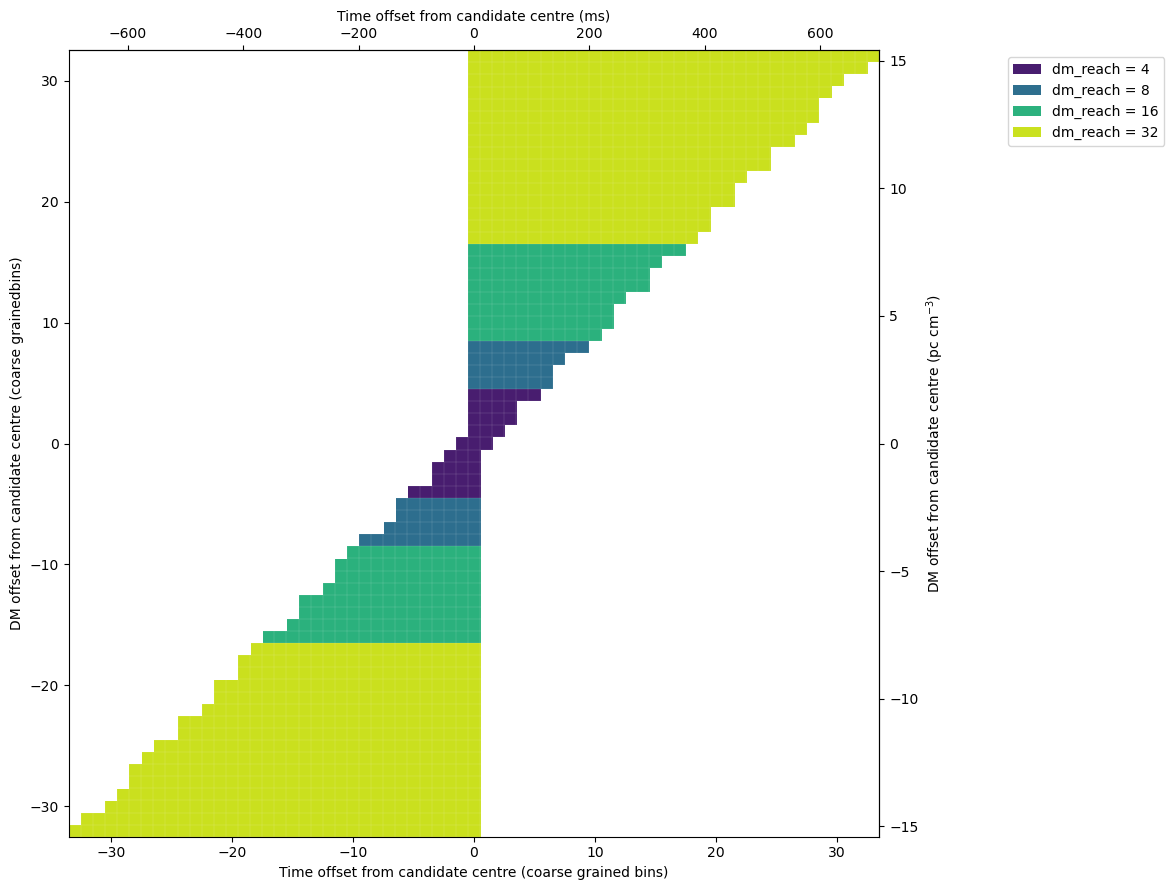

In [30]:
from pathlib import Path

import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Patch

from pirate_frb import DedispersionConfig, DedispersionPlan
from pirate_frb.Peakfinders import PeakFinderGeometry


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

tree_index = 0
dm_reaches = (4, 8, 16, 32)
waist_bins = 1

show_pixel_grid = True
save_figure = True

config_path = Path(
    "configs/dedispersion/chord_sb2_et.yml"
).resolve()


# ---------------------------------------------------------------------
# Reconstruct the production offline plan
# ---------------------------------------------------------------------

config = DedispersionConfig.from_yaml(str(config_path))

producer_plan = DedispersionPlan(
    config,
    gpu_runnable=True,
)

offline_plan = DedispersionPlan.make_incomplete_plan_from_yaml(
    config.to_yaml_string(),
    producer_plan.to_yaml_string(),
)

if not 0 <= tree_index < int(offline_plan.ntrees):
    raise IndexError(
        f"tree_index={tree_index} is outside the production plan"
    )


# ---------------------------------------------------------------------
# Construct the exact production bowtie masks
# ---------------------------------------------------------------------

bowties = []

for dm_reach in sorted(dm_reaches):
    geometry = PeakFinderGeometry.from_plan(
        offline_plan,
        tree_index,
        dm_reach=dm_reach,
        waist_bins=waist_bins,
        peakfinder="full_band",
    )

    mask = cp.asnumpy(geometry.full_band_bowtie)

    bowties.append(
        (dm_reach, geometry, mask)
    )


# ---------------------------------------------------------------------
# Place all footprints on a common pixel canvas
# ---------------------------------------------------------------------

largest_mask = bowties[-1][2]
canvas_shape = largest_mask.shape


def centre_mask(mask, output_shape):
    """Place an odd-sized bowtie mask at the centre of a larger canvas."""

    if (
        mask.shape[0] > output_shape[0]
        or mask.shape[1] > output_shape[1]
    ):
        raise ValueError("Mask is larger than the requested canvas")

    output = np.zeros(output_shape, dtype=bool)

    row_start = (output_shape[0] - mask.shape[0]) // 2
    column_start = (output_shape[1] - mask.shape[1]) // 2

    output[
        row_start:row_start + mask.shape[0],
        column_start:column_start + mask.shape[1],
    ] = mask

    return output


# Zero means that the pixel is outside the largest bowtie.
# Categories 1, 2, ... identify the smallest dm_reach that includes
# each pixel. This keeps all nested reach regions visible.
categorical_image = np.zeros(
    canvas_shape,
    dtype=np.int16,
)

previous_mask = np.zeros(
    canvas_shape,
    dtype=bool,
)

for category, (dm_reach, geometry, mask) in enumerate(
    bowties,
    start=1,
):
    centred_mask = centre_mask(
        mask,
        canvas_shape,
    )

    # The footprints should be nested as dm_reach increases.
    if np.any(previous_mask & ~centred_mask):
        raise AssertionError(
            f"The dm_reach={dm_reach} footprint is not nested "
            "inside the larger footprint"
        )

    newly_added_pixels = centred_mask & ~previous_mask

    categorical_image[newly_added_pixels] = category
    previous_mask = centred_mask


# ---------------------------------------------------------------------
# Discrete sequential colour scale
# ---------------------------------------------------------------------

reach_colours = plt.colormaps["viridis"](
    np.linspace(
        0.08,
        0.92,
        len(bowties),
    )
)

# Category zero, outside the bowtie, is white.
colour_map = ListedColormap(
    ["white", *reach_colours]
)

normalisation = BoundaryNorm(
    np.arange(
        -0.5,
        len(bowties) + 1.5,
    ),
    colour_map.N,
)


# ---------------------------------------------------------------------
# Native pixel-coordinate limits
# ---------------------------------------------------------------------

dm_radius = canvas_shape[0] // 2
time_radius = canvas_shape[1] // 2

extent = (
    -time_radius - 0.5,
    time_radius + 0.5,
    -dm_radius - 0.5,
    dm_radius + 0.5,
)


# All reaches for the same tree have the same physical sampling.
reference_geometry = bowties[0][1]

time_step_ms = (
    reference_geometry.time_step_s * 1.0e3
)

dm_step = reference_geometry.dm_step


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(11, 9)
)

ax.imshow(
    categorical_image,
    origin="lower",
    interpolation="nearest",
    aspect="equal",
    extent=extent,
    cmap=colour_map,
    norm=normalisation,
)


# Optional grid showing individual maximum-filter pixels.
if show_pixel_grid:
    ax.set_xticks(
        np.arange(
            -time_radius - 0.5,
            time_radius + 1,
        ),
        minor=True,
    )

    ax.set_yticks(
        np.arange(
            -dm_radius - 0.5,
            dm_radius + 1,
        ),
        minor=True,
    )

    ax.grid(
        which="minor",
        color="white",
        linewidth=0.25,
        alpha=0.35,
    )

    ax.tick_params(
        which="minor",
        length=0,
    )


# Bottom and left: native computational pixel offsets.
ax.set_xlabel(
    "Time offset from candidate centre (coarse grained bins)"
)

ax.set_ylabel(
    "DM offset from candidate centre (coarse grainedbins)"
)


# ---------------------------------------------------------------------
# Top axis: physical time offset in milliseconds
# ---------------------------------------------------------------------

def time_bins_to_ms(time_bins):
    return time_bins * time_step_ms


def ms_to_time_bins(time_ms):
    return time_ms / time_step_ms


top_time_axis = ax.secondary_xaxis(
    "top",
    functions=(
        time_bins_to_ms,
        ms_to_time_bins,
    ),
)

top_time_axis.set_xlabel(
    "Time offset from candidate centre (ms)"
)


# ---------------------------------------------------------------------
# Right axis: physical DM offset
# ---------------------------------------------------------------------

def dm_bins_to_physical(dm_bins):
    return dm_bins * dm_step


def physical_to_dm_bins(dm_physical):
    return dm_physical / dm_step


right_dm_axis = ax.secondary_yaxis(
    "right",
    functions=(
        dm_bins_to_physical,
        physical_to_dm_bins,
    ),
)

right_dm_axis.set_ylabel(
    r"DM offset from candidate centre (pc cm$^{-3}$)"
)


# ---------------------------------------------------------------------
# Title and legend
# ---------------------------------------------------------------------

plan_tree = offline_plan.trees[tree_index]


legend_handles = [
    Patch(
        facecolor=reach_colours[index],
        edgecolor="none",
        label=f"dm_reach = {dm_reach}",
    )
    for index, (dm_reach, _geometry, _mask)
    in enumerate(bowties)
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    bbox_to_anchor=(1.15, 1.0),
    frameon=True,
)


fig.tight_layout()





print(
    f"Tree {tree_index}: "
    f"time sampling = {time_step_ms:.6g} ms/bin, "
    f"DM sampling = {dm_step:.6g} pc cm^-3/bin"
)

for dm_reach, geometry, mask in bowties:
    print(
        f"dm_reach={dm_reach:2d}: "
        f"footprint shape={mask.shape}, "
        f"active pixels={np.count_nonzero(mask)}"
    )


plt.show()

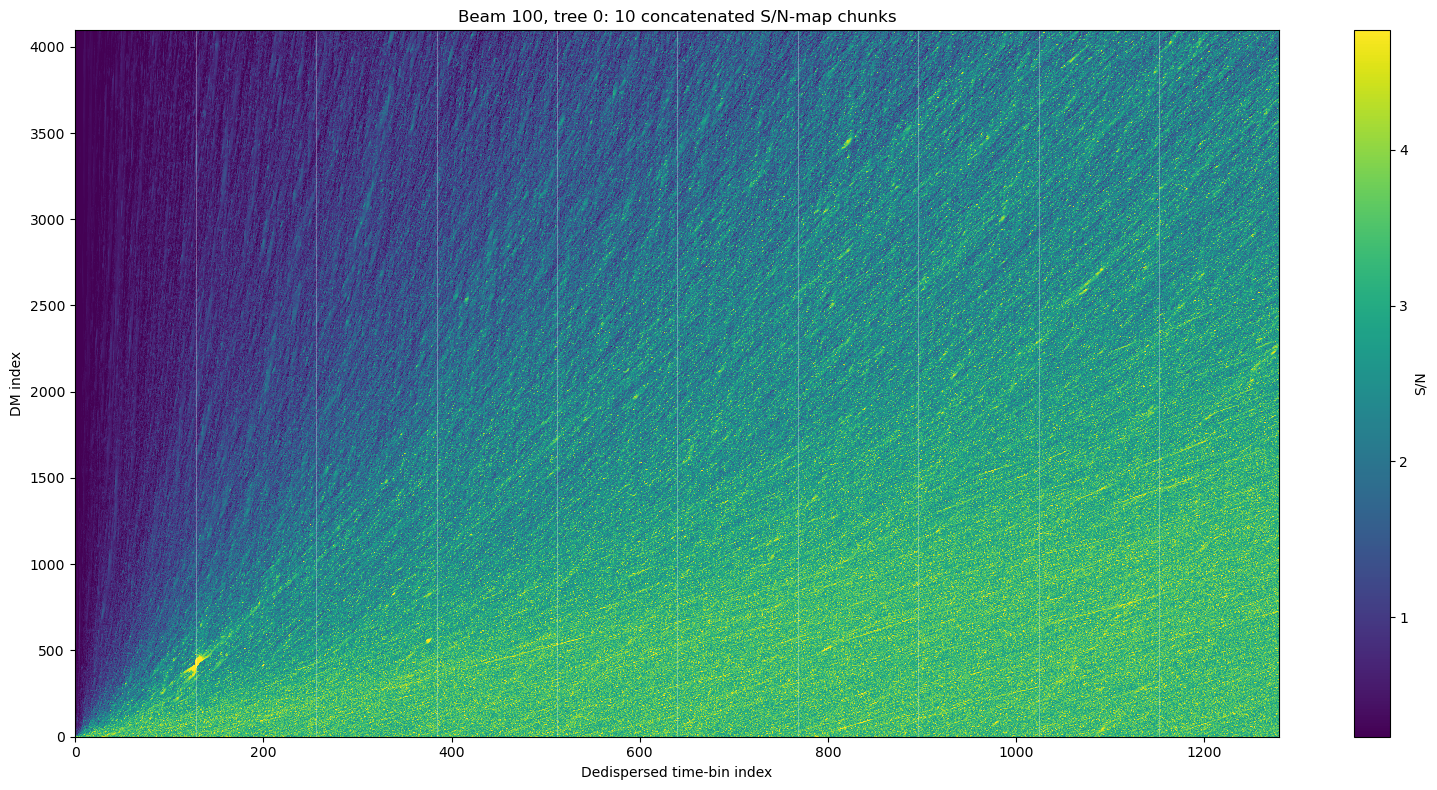

In [31]:
from pathlib import Path
import re

import asdf
import matplotlib.pyplot as plt
import numpy as np

acqdir = Path("/home/mtrudu/chordsim/grouptest")
beam_id = 100
tree_index = 0
def chunk_index(path):
    return int(re.search(r"_t(\d+)_snrmap\.asdf$", path.name).group(1))


snr_files = sorted(
    acqdir.glob(f"frame_b{beam_id}_t*_snrmap.asdf"),
    key=chunk_index,
)

snr_chunks = []

for path in snr_files:
    with asdf.open(path, lazy_load=False) as af:
        tree = af["trees"][tree_index]
        # Copy because the ASDF file closes after this block.
        snr_chunks.append(np.array(tree["snr"], copy=True))

if not snr_chunks:
    raise FileNotFoundError("No S/N-map files found")

# Concatenate consecutive chunks along the time axis.
snr_observation = np.concatenate(snr_chunks, axis=1)

# Robust colour range.
vmin, vmax = np.nanpercentile(snr_observation, (1, 99.9))

fig, ax = plt.subplots(figsize=(16, 8))

image = ax.imshow(
    snr_observation,
    origin="lower",
    aspect="auto",
    interpolation="nearest",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
)

# Mark chunk boundaries.
chunk_width = snr_chunks[0].shape[1]
for boundary in range(chunk_width, snr_observation.shape[1], chunk_width):
    ax.axvline(boundary, color="white", alpha=0.3, linewidth=0.7)

ax.set_xlabel("Dedispersed time-bin index")
ax.set_ylabel("DM index")
ax.set_title(
    f"Beam {beam_id}, tree {tree_index}: "
    f"{len(snr_chunks)} concatenated S/N-map chunks"
)

fig.colorbar(image, ax=ax, label="S/N")
fig.tight_layout()
plt.show()

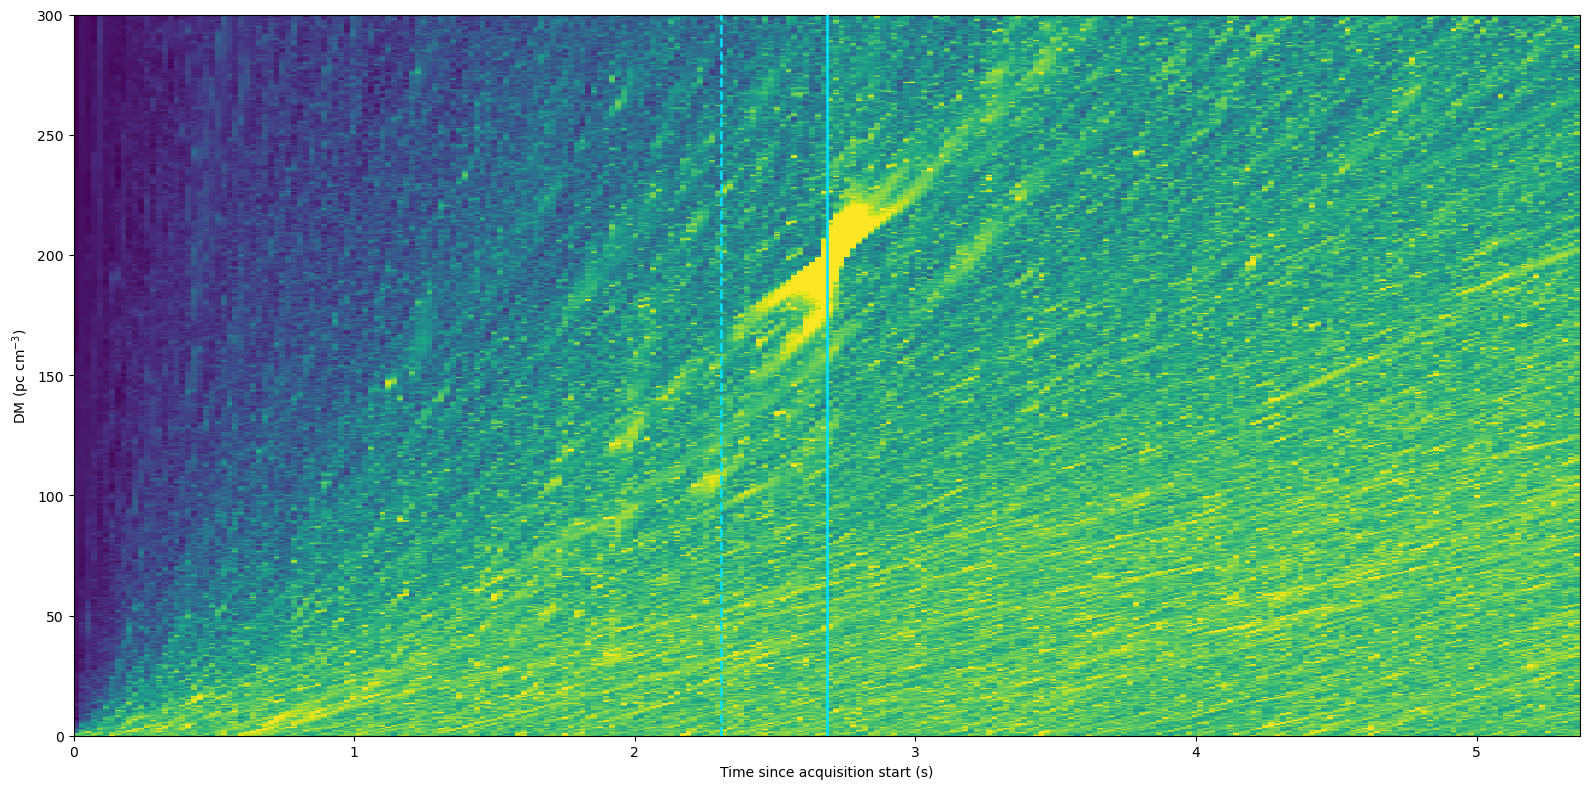

Displayed chunks: [0, 1]
Tree shape per chunk: (4096, 128)
Time sampling: 20.9715 ms/bin
DM sampling: 0.47389 pc cm^-3/bin
Bowtie shape: (17, 19)
Bowtie temporal radius: 9 bins
Retained streaming tail: 18 bins = 377.487 ms


In [34]:
from pathlib import Path
import re

import asdf
import cupy as cp
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.lines import Line2D

from pirate_frb import DedispersionPlan
from pirate_frb.Peakfinders import PeakFinderGeometry


# ---------------------------------------------------------------------
# Configuration
# ---------------------------------------------------------------------

acqdir = Path("/home/mtrudu/chordsim/grouptest")

beam_id = 100
tree_index = 0

dm_reach = 8
waist_bins = 1

number_of_chunks = 2


def chunk_index(path):
    match = re.search(
        r"_t(\d+)_snrmap\.asdf$",
        path.name,
    )

    if match is None:
        raise ValueError(
            f"Cannot determine chunk index from {path.name}"
        )

    return int(match.group(1))


# ---------------------------------------------------------------------
# Select only the first two S/N-map chunks
# ---------------------------------------------------------------------

all_snr_files = sorted(
    acqdir.glob(
        f"frame_b{beam_id}_t*_snrmap.asdf"
    ),
    key=chunk_index,
)

if len(all_snr_files) < number_of_chunks:
    raise FileNotFoundError(
        f"Expected at least {number_of_chunks} S/N-map files "
        f"for beam {beam_id}, found {len(all_snr_files)}"
    )

snr_files = all_snr_files[:number_of_chunks]


# ---------------------------------------------------------------------
# Load the maps and the authoritative serialized plan
# ---------------------------------------------------------------------

snr_chunks = []
source_chunk_indices = []

saved_config_yaml = None
saved_plan_yaml = None

for path in snr_files:
    with asdf.open(
        path,
        lazy_load=False,
    ) as af:
        file_config_yaml = str(
            af["config_yaml"]
        )

        file_plan_yaml = str(
            af["plan_yaml"]
        )

        if saved_config_yaml is None:
            saved_config_yaml = file_config_yaml
            saved_plan_yaml = file_plan_yaml
        else:
            if file_config_yaml != saved_config_yaml:
                raise ValueError(
                    f"Configuration differs in {path}"
                )

            if file_plan_yaml != saved_plan_yaml:
                raise ValueError(
                    f"Dedispersion plan differs in {path}"
                )

        tree = af["trees"][tree_index]

        snr = np.array(
            tree["snr"],
            copy=True,
        )

        if snr.ndim != 2:
            raise ValueError(
                f"Expected a two-dimensional S/N map, "
                f"found shape {snr.shape}"
            )

        snr_chunks.append(snr)

        source_chunk_indices.append(
            int(
                af["source"]["time_chunk_index"]
            )
        )


# Require consecutive chunks.
expected_chunk_indices = list(
    range(
        source_chunk_indices[0],
        source_chunk_indices[0] + number_of_chunks,
    )
)

if source_chunk_indices != expected_chunk_indices:
    raise ValueError(
        "Selected S/N maps are not consecutive: "
        f"{source_chunk_indices}"
    )


# Reconstruct the exact plan used to create the maps.
plan = DedispersionPlan.make_incomplete_plan_from_yaml(
    saved_config_yaml,
    saved_plan_yaml,
)

if not 0 <= tree_index < int(plan.ntrees):
    raise IndexError(
        f"tree_index={tree_index} is outside the saved plan"
    )

plan_tree = plan.trees[tree_index]


# ---------------------------------------------------------------------
# Construct the production bowtie geometry
# ---------------------------------------------------------------------

geometry = PeakFinderGeometry.from_plan(
    plan,
    tree_index,
    dm_reach=dm_reach,
    waist_bins=waist_bins,
    peakfinder="full_band",
)

bowtie_mask = cp.asnumpy(
    geometry.full_band_bowtie
)

expected_shape = (
    int(plan_tree.ndm_out),
    int(plan_tree.nt_out),
)

for index, snr in enumerate(snr_chunks):
    if snr.shape != expected_shape:
        raise ValueError(
            f"Chunk {source_chunk_indices[index]} has shape "
            f"{snr.shape}, expected {expected_shape}"
        )


# ---------------------------------------------------------------------
# Concatenate the first two chunks
# ---------------------------------------------------------------------

snr_observation = np.concatenate(
    snr_chunks,
    axis=1,
)

ndm, total_ntime = snr_observation.shape
chunk_width = snr_chunks[0].shape[1]


# ---------------------------------------------------------------------
# Construct physical DM and time coordinates
# ---------------------------------------------------------------------

dm_min = float(plan_tree.dm_min)
dm_max = float(plan_tree.dm_max)

dm_step = (
    dm_max - dm_min
) / float(ndm)

time_step_s = float(
    geometry.time_step_s
)

chunk_duration_s = (
    chunk_width * time_step_s
)

first_chunk_start_s = (
    source_chunk_indices[0]
    * chunk_duration_s
)


# Pixel edges for pcolormesh.
dm_edges = (
    dm_min
    + np.arange(ndm + 1) * dm_step
)

time_edges_s = (
    first_chunk_start_s
    + np.arange(total_ntime + 1) * time_step_s
)


# Pixel centres, used to centre the bowtie.
dm_centres = (
    dm_edges[:-1] + 0.5 * dm_step
)

time_centres_s = (
    time_edges_s[:-1] + 0.5 * time_step_s
)


# ---------------------------------------------------------------------
# Find the highest finite S/N pixel
# ---------------------------------------------------------------------

finite_mask = np.isfinite(
    snr_observation
)

if not np.any(finite_mask):
    raise ValueError(
        "The displayed S/N maps contain no finite values"
    )

peak_search_map = np.where(
    finite_mask,
    snr_observation,
    -np.inf,
)

peak_dm_index, peak_time_index = np.unravel_index(
    np.argmax(peak_search_map),
    snr_observation.shape,
)

peak_snr = float(
    snr_observation[
        peak_dm_index,
        peak_time_index,
    ]
)

peak_dm = float(
    dm_centres[peak_dm_index]
)

peak_time_s = float(
    time_centres_s[peak_time_index]
)


# ---------------------------------------------------------------------
# Place the bowtie around the highest S/N pixel
# ---------------------------------------------------------------------

# Add a one-pixel false border. This allows contour() to draw a complete
# closed boundary even where the production mask reaches its own edges.
padded_bowtie = np.pad(
    bowtie_mask.astype(np.uint8),
    pad_width=1,
    mode="constant",
    constant_values=0,
)

dm_offset_bins = np.arange(
    -geometry.dm_radius - 1,
    geometry.dm_radius + 2,
)

time_offset_bins = np.arange(
    -geometry.time_radius - 1,
    geometry.time_radius + 2,
)

bowtie_dm_coordinates = (
    peak_dm
    + dm_offset_bins * dm_step
)

bowtie_time_coordinates_s = (
    peak_time_s
    + time_offset_bins * time_step_s
)


# ---------------------------------------------------------------------
# Production streaming-buffer boundaries
# ---------------------------------------------------------------------

# OfflinePeakExtractor stores exactly 2*time_radius columns from the
# previous work array. For the first seam, this is the region:
#
#     [seam - 2*time_radius, seam]
#
retained_buffer_columns = (
    2 * int(geometry.time_radius)
)

if retained_buffer_columns > chunk_width:
    raise ValueError(
        "The retained streaming buffer is wider than one chunk; "
        "this plotting cell assumes it fits within the first chunk"
    )

chunk_seam_time_s = (
    first_chunk_start_s
    + chunk_width * time_step_s
)

buffer_start_time_s = (
    chunk_seam_time_s
    - retained_buffer_columns * time_step_s
)


# ---------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------

vmin, vmax = np.nanpercentile(
    snr_observation,
    (1.0, 99.9),
)

fig, ax = plt.subplots(
    figsize=(16, 8)
)

ax.pcolormesh(
    time_edges_s,
    dm_edges,
    snr_observation,
    shading="flat",
    cmap="viridis",
    vmin=vmin,
    vmax=vmax,
    rasterized=True,
)


# Production bowtie centred on the highest S/N map pixel.
bowtie_colour = "#ff3b30"

#ax.contour(
#    bowtie_time_coordinates_s,
#    bowtie_dm_coordinates,
#    padded_bowtie,
#    levels=(0.5,),
#    colors=(bowtie_colour,),
#    linewidths=2.0,
#    zorder=4,
#)


# Two lines enclosing the exact retained streaming tail.
buffer_colour = "#00e5ff"

ax.axvline(
    buffer_start_time_s,
    color=buffer_colour,
    linestyle="--",
    linewidth=1.8,
    zorder=3,
)

ax.axvline(
    chunk_seam_time_s,
    color=buffer_colour,
    linestyle="-",
    linewidth=1.8,
    zorder=3,
)


# ---------------------------------------------------------------------
# Labels and legend
# ---------------------------------------------------------------------

ax.set_xlabel(
    "Time since acquisition start (s)"
)

ax.set_ylabel(
    r"DM (pc cm$^{-3}$)"
)

#ax.set_title(
#    f"Beam {beam_id}, tree {tree_index}: "
#    f"first {number_of_chunks} S/N-map chunks\n"
#    f"highest S/N = {peak_snr:.3f} at "
#    f"DM = {peak_dm:.3f} pc cm$^{{-3}}$, "
#    f"time = {peak_time_s:.6f} s"
#)


legend_handles = [
    #Line2D(
    #    (0,),
    #    (0,),
    #    color=bowtie_colour,
    #    linewidth=2.0,
    #    label=f"Full-band bowtie, dm_reach = {dm_reach}",
    #),
    Line2D(
        (0,),
        (0,),
        color=buffer_colour,
        linestyle="--",
        linewidth=1.8,
        label=(
            "Retained-buffer start "
            f"({retained_buffer_columns} time bins)"
        ),
    ),
    Line2D(
        (0,),
        (0,),
        color=buffer_colour,
        linestyle="-",
        linewidth=1.8,
        label="Chunk seam / retained-buffer end",
    ),
]

#ax.legend(
#    handles=legend_handles,
#    loc="upper right",
#    framealpha=0.9,
#)

# Intentionally no colour bar.
ax.set_ylim(0.0, 300.0)  # pc cm^-3
fig.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# Useful diagnostics
# ---------------------------------------------------------------------

print(
    f"Displayed chunks: {source_chunk_indices}"
)

print(
    f"Tree shape per chunk: {expected_shape}"
)

print(
    f"Time sampling: {time_step_s * 1.0e3:.6g} ms/bin"
)

print(
    f"DM sampling: {dm_step:.6g} pc cm^-3/bin"
)

print(
    f"Bowtie shape: {bowtie_mask.shape}"
)

print(
    f"Bowtie temporal radius: {geometry.time_radius} bins"
)

print(
    f"Retained streaming tail: {retained_buffer_columns} bins "
    f"= {retained_buffer_columns * time_step_s * 1.0e3:.6g} ms"
)

In [33]:
import asdf
import numpy as np

path = "/home/mtrudu/chordsim/grouptest/grouptest_candidates.asdf"

with asdf.open(path, lazy_load=False) as af:
    print("Top-level keys:", list(af.tree.keys()))

    candidates = af.tree["members"]
    print("Candidate columns:", list(candidates.keys()))

    n = len(candidates["candidate_id"])
    print("Number of candidates:", n)

    columns = (
        "candidate_id",
        "event_id",
        "beam_id",
        "tree",
        "snr",
        "dm",
        "toa_sample_abs",
        "width_ms",
        "source_chunk_index",
        "idm",
        "itime",
        "edge_flags",
    )

    for i in range(min(n, 20)):
        print({
            name: np.asarray(candidates[name])[i].item()
            for name in columns
        })

Top-level keys: ['asdf_library', 'history', 'coverage', 'events', 'format', 'format_version', 'members', 'metadata']
Candidate columns: ['argmax_token', 'beam_id', 'candidate_id', 'dm', 'dm_step', 'edge_flags', 'event_id', 'freq_hi_MHz', 'freq_lo_MHz', 'idm', 'itime', 'primary_tree_index', 'snr', 'source_chunk_index', 'time_step_samples', 'toa_sample_abs', 'tree', 'width_ms', 'width_samp']
Number of candidates: 1
{'candidate_id': 0, 'event_id': 0, 'beam_id': 100, 'tree': 0, 'snr': 48.1875, 'dm': 199.87544689683827, 'toa_sample_abs': 2044.0514862967711, 'width_ms': 3.9321600000000005, 'source_chunk_index': 0, 'idm': 421, 'itime': 127, 'edge_flags': 16}
